L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 5. Differential Form Operations

## 5.1 Basic Differential Form Operations

### 5.1.1 Defining Forms and Taking Their Components

2-form을 정의한다:

In [2]:
Fdefine[w2, 2]

0-form, 1-form, 3-form을 정의한다:

In [3]:
Fdefine[{f, w1, w3}, {0, 1, 3}]

In [4]:
{f, w1, w2, w3}

{f, w1, w2, w3}

0-form인가를 확인한다:

In [5]:
ZeroDegreeQ /@ %

{True, False, False, False}

미분형식(Differential Form)의 degree 또는 랭크를 얻는다:

In [6]:
DegreeForm /@ %%

{0, 1, 2, 3}

미분형식을 IndexedTensor로 변환한다:

In [7]:
ToTensor[w3, {la, lb, lc}]

w3[la, lb, lc]

IndexedTensor 표기에서 미분형식은 완전 반대칭 텐서이다.

In [8]:
{w3[lb, la, lc], w2[lb, la]}

{w3[lb, la, lc], w2[lb, la]}

In [9]:
% // TindexSort

{-w3[la, lb, lc], -w2[la, lb]}

In [10]:
ZeroDegreeQ[w3[la, lb, lc]]

True

In [11]:
DegreeForm /@ {w3[la, lb, lc], w3}

{0, 3}

미분형식의 좌표계 표현을 얻기 위해 시공간을 3차원으로 설정하고, Indexed 0-form을 정의한다:

In [12]:
SetDimension[3];
Fdefine[x[ua], 0]

2-form `w2`의 좌표 표현이다:

w2[la, lb] XP[XD[x[ua]], XD[x[ub]]]
-----------------------------------
                 2
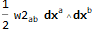

In [14]:
1/2 ToTensor[w2, {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

In [15]:
SumDum[%] // TindexSort

w2[-1, -2] XP[XD[x[1]], XD[x[2]]] + w2[-1, -3] XP[XD[x[1]], XD[x[3]]] + 
 
>   w2[-2, -3] XP[XD[x[2]], XD[x[3]]]

In [16]:
CoordRep[w2]

w2[-1, -2] XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[2]]] + 
 
>   w2[-1, -3] XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[3]]] + 
 
>   w2[-2, -3] XP[XD[mTensor`Private`coordX[2]], XD[mTensor`Private`coordX[3]]]

원통 좌표계로 설정하자:

In [17]:
SetComponents[x[ua], {r, \[Theta], z}]

3-form `w3`의 좌표 표현이다:

w3[la, lb, lc] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
--------------------------------------------------
                        6
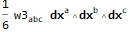

In [18]:
1/3! ToTensor[w3, {la, lb, lc}] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]

In [19]:
% // SumDum // TindexSort

-(w3[-1, -2, -3] XP[XD[r], XD[z], XD[θ]])

In [20]:
CoordRep[w3, {r, \[Theta], z}]

-(w3[-1, -2, -3] XP[XD[r], XD[z], XD[θ]])

In [21]:
CoordRep[w3]

w3[-1, -2, -3] XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[2]], 
 
>    XD[mTensor`Private`coordX[3]]]

### 5.1.2 The Exterior Product

In [22]:
ClearDimension[]  (* default *)

미분형식들 사이의 외적(Exterior Product)을 구한다:

In [23]:
XP[f, w1]

f w1

In [24]:
XP[w1, w3]

XP[w1, w3]

외적의 순서가 자동적으로 조정된다:

In [25]:
XP[w3, w1]

-XP[w1, w3]

랭크가 홀수인 경우 자기 자신과의 외적은 `0`이다:

In [26]:
{XP[w2, w1], XP[w2, w2], XP[w3, w3], XP[w1, w1]}

{XP[w1, w2], XP[w2, w2], 0, 0}

외적 `XP`의 인자 개수는 제한이 없다:

In [27]:
XP[w3, w2, w1, w2, w2]

-XP[w1, w2, w2, w2, w3]

미분형식의 IndexedTensor 표현은 완전 반대칭 텐서이다. 따라서 랭크가 큰 미분표현의 `ToTensor` 함수의 결과는 연산도 오래 걸리고, 출력 결과도 좋지 않다:

In [28]:
ToTensor[XP[w1, w2], {la, lb, lc}]

w1[lc] w2[la, lb] - w1[lb] w2[la, lc] + w1[la] w2[lb, lc]

-(w1[lf] w2[ld, le] w3[la, lb, lc]) + w1[le] w2[ld, lf] w3[la, lb, lc] - 
 
>   w1[ld] w2[le, lf] w3[la, lb, lc] + w1[lf] w2[lc, le] w3[la, lb, ld] - 
 
>   w1[le] w2[lc, lf] w3[la, lb, ld] + w1[lc] w2[le, lf] w3[la, lb, ld] - 
 
>   w1[lf] w2[lc, ld] w3[la, lb, le] + w1[ld] w2[lc, lf] w3[la, lb, le] - 
 
>   w1[lc] w2[ld, lf] w3[la, lb, le] + w1[le] w2[lc, ld] w3[la, lb, lf] - 
 
>   w1[ld] w2[lc, le] w3[la, lb, lf] + w1[lc] w2[ld, le] w3[la, lb, lf] - 
 
>   w1[lf] w2[lb, le] w3[la, lc, ld] + w1[le] w2[lb, lf] w3[la, lc, ld] - 
 
>   w1[lb] w2[le, lf] w3[la, lc, ld] + w1[lf] w2[lb, ld] w3[la, lc, le] - 
 
>   w1[ld] w2[lb, lf] w3[la, lc, le] + w1[lb] w2[ld, lf] w3[la, lc, le] - 
 
>   w1[le] w2[lb, ld] w3[la, lc, lf] + w1[ld] w2[lb, le] w3[la, lc, lf] - 
 
>   w1[lb] w2[ld, le] w3[la, lc, lf] - w1[lf] w2[lb, lc] w3[la, ld, le] + 
 
>   w1[lc] w2[lb, lf] w3[la, ld, le] - w1[lb] w2[lc, lf] w3[la, ld, le] + 
 
>   w1[le] w2[lb, lc] w3[la, ld, lf] - w1[lc] w2[lb, le] w3[la, ld, lf] + 
 
>   w1[lb] w2[lc, le] w3[la, ld, lf] - w1[ld] w2[lb, lc] w3[la, le, lf] + 
 
>   w1[lc] w2[lb, ld] w3[la, le, lf] - w1[lb] w2[lc, ld] w3[la, le, lf] + 
 
>   w1[lf] w2[la, le] w3[lb, lc, ld] - w1[le] w2[la, lf] w3[lb, lc, ld] + 
 
>   w1[la] w2[le, lf] w3[lb, lc, ld] - w1[lf] w2[la, ld] w3[lb, lc, le] + 
 
>   w1[ld] w2[la, lf] w3[lb, lc, le] - w1[la] w2[ld, lf] w3[lb, lc, le] + 
 
>   w1[le] w2[la, ld] w3[lb, lc, lf] - w1[ld] w2[la, le] w3[lb, lc, lf] + 
 
>   w1[la] w2[ld, le] w3[lb, lc, lf] + w1[lf] w2[la, lc] w3[lb, ld, le] - 
 
>   w1[lc] w2[la, lf] w3[lb, ld, le] + w1[la] w2[lc, lf] w3[lb, ld, le] - 
 
>   w1[le] w2[la, lc] w3[lb, ld, lf] + w1[lc] w2[la, le] w3[lb, ld, lf] - 
 
>   w1[la] w2[lc, le] w3[lb, ld, lf] + w1[ld] w2[la, lc] w3[lb, le, lf] - 
 
>   w1[lc] w2[la, ld] w3[lb, le, lf] + w1[la] w2[lc, ld] w3[lb, le, lf] - 
 
>   w1[lf] w2[la, lb] w3[lc, ld, le] + w1[lb] w2[la, lf] w3[lc, ld, le] - 
 
>   w1[la] w2[lb, lf] w3[lc, ld, le] + w1[le] w2[la, lb] w3[lc, ld, lf] - 
 
>   w1[lb] w2[la, le] w3[lc, ld, lf] + w1[la] w2[lb, le] w3[lc, ld, lf] - 
 
>   w1[ld] w2[la, lb] w3[lc, le, lf] + w1[lb] w2[la, ld] w3[lc, le, lf] - 
 
>   w1[la] w2[lb, ld] w3[lc, le, lf] + w1[lc] w2[la, lb] w3[ld, le, lf] - 
 
>   w1[lb] w2[la, lc] w3[ld, le, lf] + w1[la] w2[lb, lc] w3[ld, le, lf]
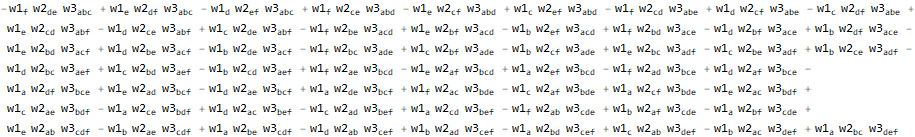

In [29]:
ToTensor[XP[w1, w2, w3], {la, lb, lc, ld, le, lf}]

시공간의 차원을 설정한다:

In [30]:
SetDimension[3]

시공간의 차원보다 랭크가 큰 미분형식은 `0`이다:

In [31]:
{XP[w2, w2], XP[w1, w3]}

{0, 0}

3차원 시공간에서 최대 랭크는 `3`이다:

In [32]:
XP[w1, w2]

XP[w1, w2]

w1[lc] w2[la, lb] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
----------------------------------------------------- - 
                          6
 
    w1[lb] w2[la, lc] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
>   ----------------------------------------------------- + 
                              6
 
    w1[la] w2[lb, lc] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]
>   -----------------------------------------------------
                              6
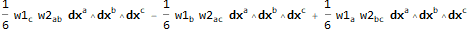

In [33]:
1/3! ToTensor[%, {la, lb, lc}] XP[XD[x[ua]], XD[x[ub]], XD[x[uc]]]

In [34]:
% // SumDum // TindexSort // CollectForm

(-(w1[-1] w2[-2, -3]) + w1[-2] w2[-1, -3] - w1[-3] w2[-1, -2]) XP[XD[r], XD[z], XD[θ]]

In [35]:
CoordRep[XP[w1, w2], {r, \[Theta], z}]

(-(w1[-1] w2[-2, -3]) + w1[-2] w2[-1, -3] - w1[-3] w2[-1, -2]) XP[XD[r], XD[z], XD[θ]]

In [36]:
CoordRep[XP[w1, w2]]

(w1[-1] w2[-2, -3] - w1[-2] w2[-1, -3] + w1[-3] w2[-1, -2]) 
 
>   XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[2]], 
 
>    XD[mTensor`Private`coordX[3]]]

### 5.1.3 The Exterior Derivative

랭크 `p`인 미분형식의 외미분(Exterior Derivative)은 랭크가 `p+1`인 미분형식이다.

In [37]:
XD[f]

XD[f[]]

In [38]:
ToTensor[%, {la}]

CD[la, f[]]

In [39]:
% // CDtoGamma

BD[la, f[]]

In [40]:
expr = XD[w1]

XD[w1[]]

In [41]:
ToTensor[%, {la, lb}]

CD[la, w1[lb]] - CD[lb, w1[la]]

In [42]:
% // CDtoGamma

BD[la, w1[lb]] - BD[lb, w1[la]] - GammaCD[la, lb, uc] w1[lc] + GammaCD[lb, la, uc] w1[lc]

In [43]:
% // TindexSort

BD[la, w1[lb]] - BD[lb, w1[la]]

외미분을 IndexedTensor로 변환할 때 공변 도함수 대신 보통 도함수를 사용하도록 설정한다:

In [44]:
Off[XDtoCDfrag]

In [45]:
ToTensor[expr, {la, lb}]

BD[la, w1[lb]] - BD[lb, w1[la]]

In [46]:
XD[w2]

XD[w2[]]

In [47]:
ToTensor[%, {la, lb, lc}]

BD[la, w2[lb, lc]] - BD[lb, w2[la, lc]] + BD[lc, w2[la, lb]]

시공간을 2차원으로 설정한다:

In [48]:
SetDimension[2]

성분이 각각 $u$, $v$인 1-form의 좌표 표현이다:

In [49]:
oneform = u XD[x] + v XD[y]

v XD[y] + u XD[x[]]

In [50]:
XDoneform = XD[oneform]

XP[XD[u], XD[x[]]] + XP[XD[v], XD[y]]

1-form $du$의 좌표 표현이다:

In [51]:
XD[u] ^= D[u[x,y],x] XD[x] + D[u[x,y],y] XD[y]

(0,1)                  (1,0)
XD[y] u     [x, y] + XD[x[]] u     [x, y]

1-form $dv$의 좌표 표현이다:

In [52]:
XD[v] ^= D[v[x,y],x] XD[x] + D[v[x,y],y] XD[y]

(0,1)                  (1,0)
XD[y] v     [x, y] + XD[x[]] v     [x, y]

In [53]:
XDoneform // Factor

(0,1)          (1,0)
XP[XD[y], XD[x[]]] (u     [x, y] - v     [x, y])

2차원에서 2-form의 외미분은 `0`이다:

In [54]:
twoform = u XP[XD[x], XD[y]]

-(u XP[XD[y], XD[x[]]])

In [55]:
XD[twoform]

0

$du \wedge dv$의 좌표 표현이다:

In [56]:
XP[XD[u], XD[v]]

(0,1)        (1,0)
-(XP[XD[y], XD[x[]]] v     [x, y] u     [x, y]) + 
 
                        (0,1)        (1,0)
>   XP[XD[y], XD[x[]]] u     [x, y] v     [x, y]

In [57]:
% // Factor

(0,1)        (1,0)          (0,1)        (1,0)
-(XP[XD[y], XD[x[]]] (v     [x, y] u     [x, y] - u     [x, y] v     [x, y]))

동일한 연산을 미분형식의 좌표 표현으로 직접 구하자:

In [58]:
SetComponents[x[ua], {x, y}]

In [59]:
XP[XD[s], XD[t]]

XP[XD[s], XD[t]]

-(BD[la, t] BD[lb, s] XP[XD[x[ua]], XD[x[ub]]])
----------------------------------------------- + 
                       2
 
    BD[la, s] BD[lb, t] XP[XD[x[ua]], XD[x[ub]]]
>   --------------------------------------------
                         2
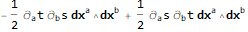

In [60]:
1/2! ToTensor[%, {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

In [61]:
% // SumDum // TindexSort // CollectForm

(-(BD[-2, t] BD[-1, s]) + BD[-2, s] BD[-1, t]) XP[XD[y], XD[x[]]]

In [62]:
CoordRep[XP[XD[s], XD[t]], {x, y}]

(-(BD[-2, t] BD[-1, s]) + BD[-2, s] BD[-1, t]) XP[XD[y], XD[x[]]]

$dr \wedge d\theta$를 $dx \wedge dy$로 표현하자:

In [63]:
On[EvaluateBDFlag]

In [64]:
SetCoordinates[{x, y}]

In [65]:
r = Sqrt[x^2 + y^2]; \[Theta] = ArcTan[x, y];

-(x BD[la, ArcTan[x, y]] BD[lb, x] XP[XD[x[ua]], XD[x[ub]]])
------------------------------------------------------------ - 
                              2    2
                      2 Sqrt[x  + y ]
 
    y BD[la, ArcTan[x, y]] BD[lb, y] XP[XD[x[ua]], XD[x[ub]]]
>   --------------------------------------------------------- + 
                                 2    2
                         2 Sqrt[x  + y ]
 
    x BD[la, x] BD[lb, ArcTan[x, y]] XP[XD[x[ua]], XD[x[ub]]]
>   --------------------------------------------------------- + 
                                 2    2
                         2 Sqrt[x  + y ]
 
    y BD[la, y] BD[lb, ArcTan[x, y]] XP[XD[x[ua]], XD[x[ub]]]
>   ---------------------------------------------------------
                                 2    2
                         2 Sqrt[x  + y ]
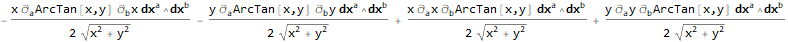

In [68]:
1/2! ToTensor[
  XP[XD[r], XD[\[Theta]]], {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

2               2
        x               y
(-(------------) - ------------) XP[XD[y], XD[x[]]]
     2    2 3/2      2    2 3/2
   (x  + y )       (x  + y )
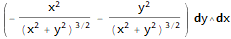

In [69]:
% // SumDum // TindexSort // CollectForm

XP[XD[y], XD[x[]]]
-(------------------)
          2    2
    Sqrt[x  + y ]
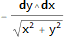

In [70]:
% // Simplify

XP[XD[y], XD[x[]]]
-(------------------)
          2    2
    Sqrt[x  + y ]
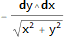

In [72]:
CoordRep[XP[XD[r], XD[\[Theta]]], {x, y}] // Simplify

In [73]:
r =.; \[Theta] =.;  (* default *)

$dx \wedge dy$를 $dr \wedge d\theta$로 표현하자:

In [74]:
SetCoordinates[{r, \[Theta]}]

In [75]:
SetComponents[x[ua], {r, \[Theta]}]

In [76]:
xx = r Cos[\[Theta]]; yy = r Sin[\[Theta]];

In [77]:
aRule = {XD[Sin[\[Theta]]] -> Cos[\[Theta]] XD[\[Theta]], 
   XD[Cos[\[Theta]]] -> -Sin[\[Theta]] XD[\[Theta]]};

In [78]:
XP[XD[xx], XD[yy]]

-(r Sin[θ] XP[XD[r], XD[Cos[θ]]]) + r Cos[θ] XP[XD[r], XD[Sin[θ]]] + 
 
     2
>   r  XP[XD[Cos[θ]], XD[Sin[θ]]]

In [79]:
% /. aRule // Simplify

r XP[XD[r], XD[θ]]

In [80]:
ClearDimension[]  (* default *)

임의의 미분형식 $\omega$의 $d^2 \omega$는 `0`이다:

In [81]:
XP[w1, w2, w3]

XP[w1, w2, w3]

In [82]:
% // XD

-XP[w1, w2, XD[w3[]]] - XP[w1, XD[w2[]], w3] + XP[XD[w1[]], w2, w3]

In [83]:
% // XD

0

In [84]:
On[XDtoCDfrag]  (* default *)

## 5.2 Advanced Differential Form Operations

### 5.2.1 The Lie Derivative

In [85]:
Tdefine[v[ua]]; Fdefine[w, 2]

벡터 `v`에 의한 2-form `w`의 Lie 도함수:

In [88]:
lie = LD[v, w]

LD[v, w]

In [89]:
ToTensor[lie, {la, lb}]

LD[v, w[la, lb]]

공식:
\begin{align*}
  \mathcal{L}_v w_{ab} &= v^c \nabla_c w_{ab}
  + (\nabla_a v^c) w_{cb} + (\nabla_b v^c) w_{ac} \\
  &= v^c \partial_c w_{ab}
  + (\partial_a v^c) w_{cb} + (\partial_b v^c) w_{ac}
\end{align*}

In [90]:
LDtoCD[%, BD]

BD[lc, w[la, lb]] v[uc] + BD[lb, v[uc]] w[la, lc] + BD[la, v[uc]] w[lc, lb]

In [91]:
%% // LDtoCD

CD[lc, w[la, lb]] v[uc] + CD[lb, v[uc]] w[la, lc] + CD[la, v[uc]] w[lc, lb]

In [92]:
% // CDtoGamma

BD[lc, w[la, lb]] v[uc] + BD[lb, v[uc]] w[la, lc] + 
 
>   GammaCD[lb, ld, uc] v[ud] w[la, lc] - GammaCD[lc, lb, ud] v[uc] w[la, ld] + 
 
>   BD[la, v[uc]] w[lc, lb] + GammaCD[la, ld, uc] v[ud] w[lc, lb] - 
 
>   GammaCD[lc, la, ud] v[uc] w[ld, lb]

In [93]:
% // Tsimplify

BD[lc, w[la, lb]] v[uc] + BD[lb, v[uc]] w[la, lc] - BD[la, v[uc]] w[lb, lc]

`LDtoXDRule[]`:
$$
  \mathcal{L}_v w = \mathcal{i}_v (dw) + d (\mathcal{i}_v w)
$$

In [94]:
lie /. LDtoXDRule[]

IP[v, XD[w[]]] + XD[IP[v, w]]

In [95]:
ToTensor[%, {la, lb}]

CD[lc, w[la, lb]] v[uc] + CD[lb, v[uc]] w[la, lc] - CD[la, v[uc]] w[lb, lc]

Lie 도함수의 좌표 표현:

In [96]:
SetDimension[3]

In [97]:
Fdefine[x[ua], 0]

LD[v, w[la, lb]] XP[XD[x[ua]], XD[x[ub]]]
-----------------------------------------
                    2
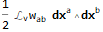

In [98]:
1/2! ToTensor[lie, {la, lb}] XP[XD[x[ua]], XD[x[ub]]]

In [99]:
% // SumDum // TindexSort

LD[v, w[-1, -3]] XP[XD[r], XD[z]] + LD[v, w[-1, -2]] XP[XD[r], XD[θ]] - 
 
>   LD[v, w[-2, -3]] XP[XD[z], XD[θ]]

In [100]:
CoordRep[lie]

LD[v, w[-1, -2]] XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[2]]] + 
 
>   LD[v, w[-1, -3]] XP[XD[mTensor`Private`coordX[1]], XD[mTensor`Private`coordX[3]]] + 
 
>   LD[v, w[-2, -3]] XP[XD[mTensor`Private`coordX[2]], XD[mTensor`Private`coordX[3]]]

In [101]:
CoordRep[lie, {r, \[Theta], z}]

LD[v, w[-1, -3]] XP[XD[r], XD[z]] + LD[v, w[-1, -2]] XP[XD[r], XD[θ]] - 
 
>   LD[v, w[-2, -3]] XP[XD[z], XD[θ]]

In [102]:
ClearDimension[]  (* default *)

외적의 Lie 도함수:

In [103]:
XP[w, w]

XP[w, w]

In [104]:
LD[v, %]

2 XP[w, LD[v, w]]

### 5.2.2 The Interior Product

벡터 `v`와 2-form `w`의 내적:

In [105]:
IP[v, w]

IP[v, w]

In [106]:
ToTensor[%, {la}]

-(v[ub] w[la, lb])

p-form $\alpha$와 q-form $\beta$에 대하여
$$
  \mathcal{i}_v (\alpha \wedge \beta)
  = (\mathcal{i}_v \alpha) \wedge \beta)
  + (-1)^p \alpha \wedge (\mathcal{i}_v \beta)
$$

In [107]:
IP[v, XP[w, w]]

2 XP[IP[v, w], w]

In [108]:
Fdefine[z, 1]

In [109]:
IP[v, XP[z, w]]

w IP[v, z] - XP[z, IP[v, w]]

In [110]:
RemoveObject[x];
RemoveObject[z]  (* default *)

내적의 좌표 표현:

In [111]:
SetDimension[3]

In [112]:
Fdefine[X[ua], 0]

In [119]:
SetComponents[X[ua], {x, y, z}]

In [120]:
ToTensor[IP[v, w], {la}] XD[X[ua]]

-(v[ub] w[la, lb] XD[X[ua]])

In [121]:
% // SumDum // TindexSort // CollectForm

(-(v[3] w[-1, -3]) - v[2] w[-1, -2]) XD[x] + 
 
>   (-(v[3] w[-2, -3]) + v[1] w[-1, -2]) XD[y] + (v[2] w[-2, -3] + v[1] w[-1, -3]) XD[z]

In [122]:
CoordRep[IP[v, w], {x, y, z}]

(-(v[3] w[-1, -3]) - v[2] w[-1, -2]) XD[x] + 
 
>   (-(v[3] w[-2, -3]) + v[1] w[-1, -2]) XD[y] + (v[2] w[-2, -3] + v[1] w[-1, -3]) XD[z]

0-form의 Lie 도함수:

In [123]:
Fdefine[f, 0]

In [124]:
LD[v, f]

LD[v, f]

In [125]:
ToTensor[%, {}]

CD[la, f] v[ua]

In [126]:
% // CDtoGamma

BD[la, f] v[ua]

### 5.2.3 The Hodge Star Operator

$p$-form에 대한 Dual 연산 (참고. R. M. Wald 문제 2-(a)):
\begin{gather*}
  ({}^*\alpha)_{b_1 \cdots b_{n-p}}
  = \frac{1}{p!} \alpha^{a_1 \cdots a_p}
  \epsilon_{a_1 \cdots a_p b_1 \cdots b_{n-p}} \\
  {}^{**} \alpha = (-1)^{\frac{n-s}{2} + p(n-p)} \alpha
\end{gather*}
여기서 $s$는 메트릭 signature이다.

In [2]:
SetDimension[4]; SetSignature[2]  (* Minkowski spacetime *)

In [3]:
Fdefine[{w1, w2, w3, w4}, {1, 2, 3, 4}]

In [4]:
HodgeStar /@ {w1, w2, w3, w4}

{HodgeStar[w1], HodgeStar[w2], HodgeStar[w3], HodgeStar[w4]}

HodgeStar는 p-form을 (n-p)-form으로 바꾼다:

In [5]:
DegreeForm /@ %

{3, 2, 1, 0}

In [6]:
w1Star = ToTensor[HodgeStar[w1], {la, lb, lc}]

Epsilon[ud, la, lb, lc] w1[ld]

In [7]:
HodgeStar@HodgeStar@w1

w1

HodgeStar의 IndexedTensor 표현:

Epsilon[ua, ub, uc, ld] Epsilon[ue, la, lb, lc] w1[le]
------------------------------------------------------
                          6
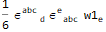

In [8]:
DualStar[w1Star, {ua, ub, uc, ld}]

In [9]:
% /. EpsilonProductRule[]

w1[ld]

Epsilon[uc, ud, la, lb] w2[lc, ld]
----------------------------------
                2
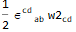

In [10]:
ToTensor[HodgeStar@w2, {la, lb}]

Epsilon[ua, ub, uc, ud] w4[la, lb, lc, ld]
------------------------------------------
                    24
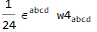

In [11]:
ToTensor[HodgeStar@w4, {}]

In [12]:
XD@HodgeStar@w3

XD[HodgeStar[w3]]

CD[lb, w3[lc, ld, le]] Epsilon[la, uc, ud, ue]
---------------------------------------------- - 
                      6
 
    CD[la, w3[lc, ld, le]] Epsilon[lb, uc, ud, ue]
>   ----------------------------------------------
                          6
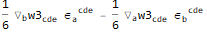

In [13]:
ToTensor[%, {la, lb}]

In [14]:
ClearDimension[]

3차원 유클리드 공간으로 설정하자:

In [15]:
MakeConstantMetric[{1, 1, 1}]

In [21]:
Fdefine[X[ua], 0];
SetComponents[X[ua], {x, y, z}]

In [23]:
Off[XDtoCDfrag];
On[EvaluateBDFlag];
SetCoordinates[{x, y, z}]

In [26]:
HodgeStar /@ {XD[x], XD[y], XD[z]}

{HodgeStar[XD[x]], HodgeStar[XD[y]], HodgeStar[XD[z]]}

BD[lc, x] Epsilon[uc, la, lb] XP[XD[X[ua]], XD[X[ub]]]
------------------------------------------------------
                          2
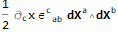

In [27]:
(1/2! ToTensor[HodgeStar@XD[x], {la, lb}]) XP[XD[X[ua]], XD[X[ub]]]

In [28]:
% // SumDum // TindexSort

Epsilon[1, -2, -3] XP[XD[y], XD[z]]

In [31]:
CoordRep[HodgeStar@XD[x], {x, y, z}]

Epsilon[1, -2, -3] XP[XD[y], XD[z]]

In [32]:
% /. Epsilon[a_, b_, c_] :> Epsilon[ToDnIndex[a], b, c]

XP[XD[y], XD[z]]

Epsilon[la, lb, lc] XP[XD[X[ua]], XD[X[ub]], XD[X[uc]]]
-------------------------------------------------------
                           6
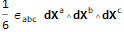

In [33]:
1/3! ToTensor[HodgeStar[1], {la, lb, lc}] XP[XD[X[ua]], XD[X[ub]], XD[X[uc]]]

In [34]:
% // SumDum // TindexSort

XP[XD[x], XD[y], XD[z]]

In [35]:
CoordRep[HodgeStar[1], {x, y, z}]

XP[XD[x], XD[y], XD[z]]

In [36]:
ClearConstantMetric[];
On[XDtoCDfrag];
Off[EvaluateBDFlag];
ClearCoordinates[];  (* default *)

### 5.2.4 The Codifferential Operator

p-form에 대한 공식:
$$
  \delta \omega
  = (-1)^{\frac{n-s}{2} + n(p-1) + 1} * d * \omega
$$
여기서 $n$은 시공간 차원, $s$는 메트릭 signature이다.

In [40]:
MakeConstantMetric[{1, 1, 1}]  (* Euclid space *)

In [41]:
Fdefine[{w0, w2, w3}, {0, 2, 3}]

`CoXD`는 p-form을 (p-1)-form으로 바꾼다:

In [42]:
CoXD[w0]

0

In [43]:
CoXD[w3]

CoXD[w3]

In [44]:
expr = ToTensor[%, {la, lb}]

-CD[uc, w3[lc, la, lb]]

모든 미분형식에 대해 $\delta^2 \omega$는 `0`이다.

In [45]:
CoXD@CoXD@w3

0

$\delta w3$의 좌표 표현:

In [46]:
Fdefine[X[ua], 0]

-(CD[uc, w3[lc, la, lb]] XP[XD[X[ua]], XD[X[ub]]])
--------------------------------------------------
                        2
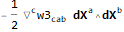

In [51]:
(1/2! expr) XP[XD[X[ua]], XD[X[ub]]]

In [52]:
% // SumDum // TindexSort

-(CD[3, w3[-1, -2, -3]] XP[XD[x], XD[y]]) + CD[2, w3[-1, -2, -3]] XP[XD[x], XD[z]] - 
 
>   CD[1, w3[-1, -2, -3]] XP[XD[y], XD[z]]

In [50]:
CoordRep[CoXD[w3], {x, y, z}]

-(CD[3, w3[-1, -2, -3]] XP[XD[x], XD[y]]) + CD[2, w3[-1, -2, -3]] XP[XD[x], XD[z]] - 
 
>   CD[1, w3[-1, -2, -3]] XP[XD[y], XD[z]]

`CoXD`의 IndexedTensor 표현:

In [54]:
CoXD[XD[w2]]

CoXD[XD[w2[]]]

In [55]:
ToTensor[%, {la, lb}]

-CD[uc, CD[la, w2[lb, lc]]] + CD[uc, CD[lb, w2[la, lc]]] - CD[uc, CD[lc, w2[la, lb]]]

In [56]:
XD[CoXD[w2]]

XD[CoXD[w2]]

In [57]:
ToTensor[%, {la, lb}]

CD[la, CD[lc, w2[lb, uc]]] - CD[lb, CD[lc, w2[la, uc]]]

In [58]:
ClearConstantMetric[]

### 5.2.5 The Hodge and Bochner Laplacian Operator

3차원 유클리드 공간의 특성으로 설정하자:

In [59]:
SetDimension[3]; SetSignature[3]

일반화 라플라스 연산자(Hodge Laplacian): $d\delta + \delta d$

In [60]:
Fdefine[w2, 2]

In [61]:
CoXD @ XD @ w2

CoXD[XD[w2[]]]

In [62]:
expr1 = ToTensor[%, {la, lb}]

-CD[uc, CD[la, w2[lb, lc]]] + CD[uc, CD[lb, w2[la, lc]]] - CD[uc, CD[lc, w2[la, lb]]]

In [63]:
XD @ CoXD @ w2

XD[CoXD[w2]]

In [64]:
expr2 = ToTensor[%, {la, lb}]

CD[la, CD[lc, w2[lb, uc]]] - CD[lb, CD[lc, w2[la, uc]]]

In [65]:
expr1 + expr2

CD[la, CD[lc, w2[lb, uc]]] - CD[lb, CD[lc, w2[la, uc]]] - CD[uc, CD[la, w2[lb, lc]]] + 
 
>   CD[uc, CD[lb, w2[la, lc]]] - CD[uc, CD[lc, w2[la, lb]]]

In [66]:
PutMetric[%, uc]

CD[la, CD[lc, w2[lb, ld]]] Metricg[uc, ud] - 
 
>   CD[lb, CD[lc, w2[la, ld]]] Metricg[uc, ud] - 
 
>   CD[ld, CD[la, w2[lb, lc]]] Metricg[uc, ud] + 
 
>   CD[ld, CD[lb, w2[la, lc]]] Metricg[uc, ud] - 
 
>   CD[ld, CD[lc, w2[la, lb]]] Metricg[uc, ud]

In [67]:
% // Absorbg

CD[la, CD[ud, w2[lb, ld]]] - CD[lb, CD[ud, w2[la, ld]]] - CD[uc, CD[la, w2[lb, lc]]] + 
 
>   CD[uc, CD[lb, w2[la, lc]]] - CD[uc, CD[lc, w2[la, lb]]]

In [68]:
lapsum = % + CD[uc, lc, w2[la, lb]]

CD[la, CD[ud, w2[lb, ld]]] - CD[lb, CD[ud, w2[la, ld]]] - CD[uc, CD[la, w2[lb, lc]]] + 
 
>   CD[uc, CD[lb, w2[la, lc]]]

In [69]:
CommuteCD[{lb, ud}, lapsum[[2]]]

-CD[ud, CD[lb, w2[la, ld]]] + RicciCD[lb, uc] w2[la, lc] - 
 
>   RiemannCD[lb, ud, la, uc] w2[lc, ld]

In [70]:
ReplacePart[lapsum, 2 -> %]

CD[la, CD[ud, w2[lb, ld]]] - CD[uc, CD[la, w2[lb, lc]]] + CD[uc, CD[lb, w2[la, lc]]] - 
 
>   CD[ud, CD[lb, w2[la, ld]]] + RicciCD[lb, uc] w2[la, lc] - 
 
>   RiemannCD[lb, ud, la, uc] w2[lc, ld]

연산 후의 ResetDummies 함수가 자동적으로 동작하므로 (출력 결과만 보면 동일해 보이는) 아래의 두 명령을 한 개의 명령 `lapsum = % // Tsimplify`으로 줄이면 안된다.

주의: 시작

In [73]:
% // Tsimplify

CD[la, CD[lc, w2[lb, uc]]] - CD[lc, CD[la, w2[lb, uc]]] + RicciCD[lb, lc] w2[la, uc] - 
 
>   RiemannCD[la, lc, lb, ld] w2[uc, ud]

In [74]:
lapsum = %

CD[la, CD[lc, w2[lb, uc]]] - CD[lc, CD[la, w2[lb, uc]]] + RicciCD[lb, lc] w2[la, uc] - 
 
>   RiemannCD[la, lc, lb, ld] w2[uc, ud]

주의: 끝

In [75]:
CommuteCD[{lc, la}, lapsum[[2]]]

-CD[la, CD[lc, w2[lb, uc]]] - RicciCD[la, lc] w2[lb, uc] - 
 
>   RiemannCD[lc, la, lb, ud] w2[ld, uc]

In [76]:
ReplacePart[lapsum, 2 -> %]

RicciCD[lb, lc] w2[la, uc] - RicciCD[la, lc] w2[lb, uc] - 
 
>   RiemannCD[lc, la, lb, ud] w2[ld, uc] - RiemannCD[la, lc, lb, ld] w2[uc, ud]

In [77]:
% // Tsimplify

RicciCD[lb, lc] w2[la, uc] - RicciCD[la, lc] w2[lb, uc] - 
 
>   2 RiemannCD[la, lc, lb, ld] w2[uc, ud]

따라서 일반화 라플라스 연산자와 보통의 라플라스 연산자의 합을 2-form에 적용하면 곡률 텐서에 의존하는 항만 남는다.